<h2 style="background-color:violet; color:white; padding:10px; border-radius:10px;">
  <span style="color:pink;">Exercice :</span> Fonctions d’appartenance et degrés d’appartenance
</h2>


<h2 style="color:violet;">
  <span style="color:orange;">LAILA MARQOUM</span> — IID3
</h2>


<div class="objectif">
  <h3>Objectif de l’exercice :</h3>
  <ul>
    <li>Définir les <strong>ensembles flous</strong> correspondant aux sensations thermiques : <em>froid</em>, <em>agréable</em> et <em>chaud</em> ;</li>
    <li>Construire leurs <strong>fonctions d’appartenance µ(x)</strong> ;</li>
    <li>Calculer les <strong>degrés d’appartenance µ(u)</strong> pour deux températures données : <strong>u(18)</strong> et <strong>u(28)</strong> ;</li>
    <li>Interpréter les résultats obtenus.</li>
  </ul>
</div>

In [5]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

In [6]:
temperature = ctrl.Antecedent(np.arange(10, 50, 1), 'temperature')
temperature

Antecedent: temperature

In [7]:
vitesse = ctrl.Consequent(np.arange(0, 100, 1), 'vitesse')
vitesse.automf(names=['faible', 'moyenne', 'elevée'])
vitesse

Consequent: vitesse

In [8]:
temperature['froid'] = fuzz.trimf(temperature.universe, [10, 10, 20])
temperature['agreable'] = fuzz.trimf(temperature.universe, [15, 25, 30])
temperature['chaud'] = fuzz.trimf(temperature.universe, [27, 50, 50])

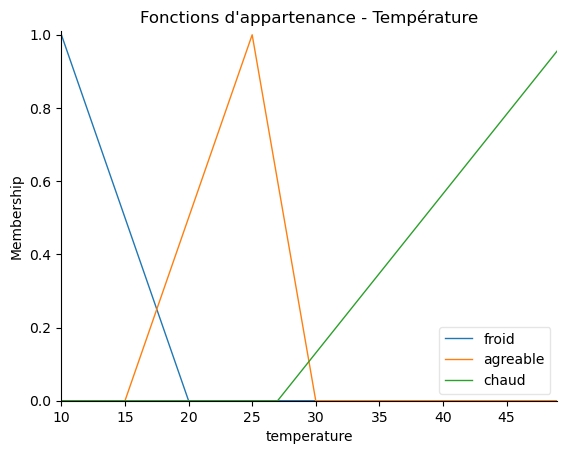

In [11]:

temperature.view()
plt.title("Fonctions d'appartenance - Température")
plt.show()  # <- Force l'affichage de la figure


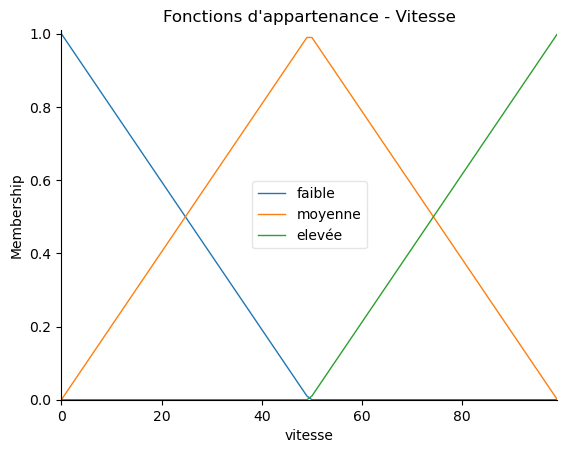

In [12]:
vitesse.view()
plt.title('Fonctions d\'appartenance - Vitesse')
plt.show()

In [13]:
rule1 = ctrl.Rule(temperature['froid'], vitesse['faible'])
rule2 = ctrl.Rule(temperature['agreable'], vitesse['moyenne'])
rule3 = ctrl.Rule(temperature['chaud'], vitesse['elevée'])

In [14]:
vitesse_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
vitesse_simulator = ctrl.ControlSystemSimulation(vitesse_ctrl)

In [15]:
print(fuzz.interp_membership(temperature.universe, temperature['froid'].mf, 18))
print(fuzz.interp_membership(temperature.universe, temperature['agreable'].mf, 18))
print(fuzz.interp_membership(temperature.universe, temperature['chaud'].mf, 18))

0.2
0.3
0.0


In [16]:
vitesse_simulator.input['temperature'] = 18
vitesse_simulator.compute()
print(vitesse_simulator.output['vitesse'])

47.755282778056845


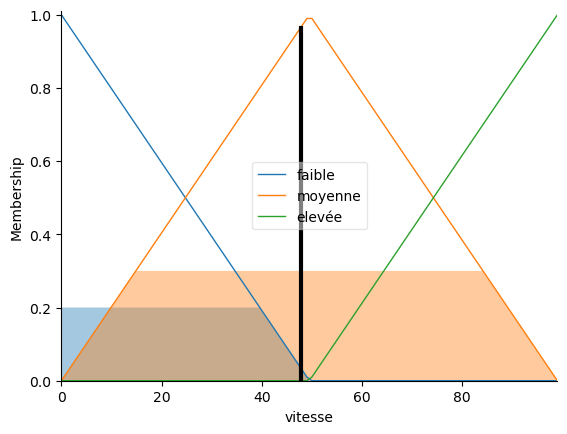

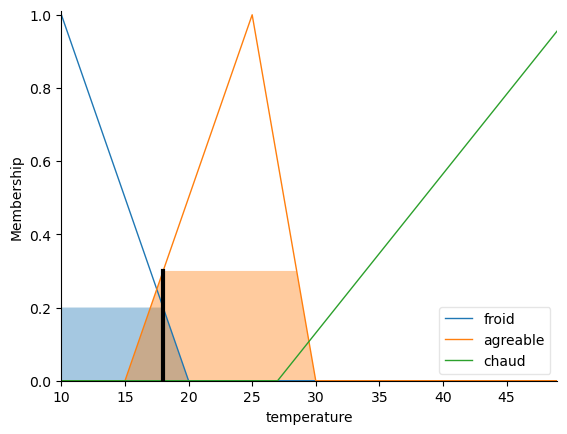

In [17]:
vitesse.view(sim=vitesse_simulator)
temperature.view(sim=vitesse_simulator)

In [18]:
print(fuzz.interp_membership(temperature.universe, temperature['froid'].mf, 28))
print(fuzz.interp_membership(temperature.universe, temperature['agreable'].mf, 28))
print(fuzz.interp_membership(temperature.universe, temperature['chaud'].mf, 28))

0.0
0.4
0.043478260869565216


In [19]:
vitesse_simulator.input['temperature'] = 28
vitesse_simulator.compute()
print(vitesse_simulator.output['vitesse'])

49.573870307174836


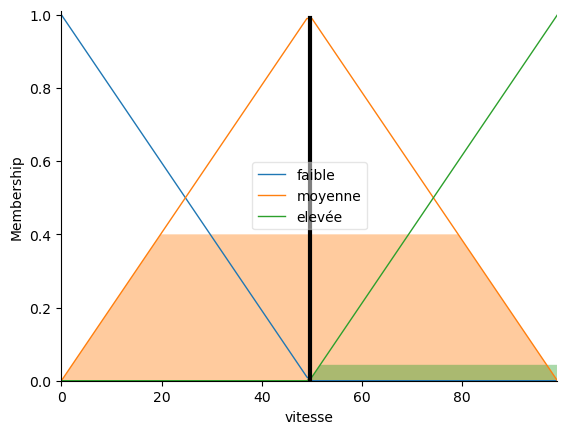

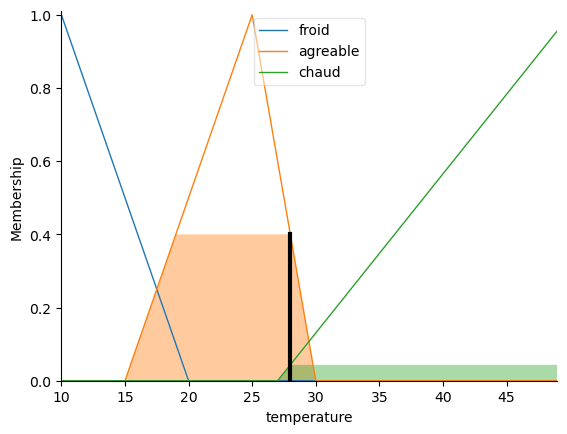

In [20]:
vitesse.view(sim=vitesse_simulator)
temperature.view(sim=vitesse_simulator)